# Time Series Stock Forecast

# Libraries

In [1]:
!date

Mon Apr 13 14:08:08 CDT 2026


In [4]:
# First, install the required packages
!pip install prophet
!pip install yfinance  # Install the missing yfinance package
!pip install pandas-datareader  # Also install pandas-datareader as it's imported

# Then load required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from prophet import Prophet
import yfinance as yf  # Now this will work
from pandas_datareader import data as pdr
import math
from sklearn.metrics import mean_absolute_error
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.model_selection import train_test_split
# import plotly.graph_objs as go # this can be solved by installing '!pip install ipywidgets'

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.6 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=f41243d8e54e6a64da84e580bd6901612027c69add9129ec955cdb2652e6f21b
  Stored in directory: /Users/asrar/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [yfinance]4/6 [curl_cffi]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 29.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas-datareader]


In [13]:
# First, install the required packages
!pip install prophet
!pip install yfinance  # Add this line to install yfinance
!pip install pandas-datareader  # Also install pandas-datareader for completeness

# Then load required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from prophet import Prophet
import yfinance as yf  # Now this will work
from pandas_datareader import data as pdr
import math
from sklearn.metrics import mean_absolute_error
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.model_selection import train_test_split
# import plotly.graph_objs as go # this can be solved by installing '!pip install ipywidgets'

In [14]:
# load required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from prophet import Prophet
# import fix_yahoo_finance as yf
import yfinance as yf
from pandas_datareader import data as pdr
import math
from sklearn.metrics import mean_absolute_error
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.model_selection import train_test_split
# import plotly.graph_objs as go # this can be solved by installing '!pip install ipywidgets'

# Selecting company with the start and end date of its stock prices.
## download dataset from Yahoo based on the user input (company, start date, end date)

In [15]:
a={'Apple':'AAPL','Tesla':'TSLA','Amazon':'AMZN','Intel':'INTC'}
a['Apple']

'AAPL'

In [16]:
# stock = 'RAD' 
# start = "2015-01-01"
# end = "2017-12-08"

stock = 'AAPL'
start = "2010-01-01"
end = "2020-03-31"
# df = pdr.get_data_yahoo(stock, start, end)
df = yf.download(stock, start, end)

dfa=df

[*********************100%***********************]  1 of 1 completed


In [17]:
yf.__version__

'1.2.2'

In [18]:
yf.__version__

'1.2.2'

In [19]:
df.shape

(2577, 5)

In [20]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.412384,6.427065,6.363544,6.395005,493729600
2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2010-01-06,6.321296,6.448939,6.314704,6.423470,552160000
2010-01-07,6.309609,6.352157,6.263766,6.344667,477131200
2010-01-08,6.351558,6.352158,6.264067,6.301220,447610800


# Closing Price

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


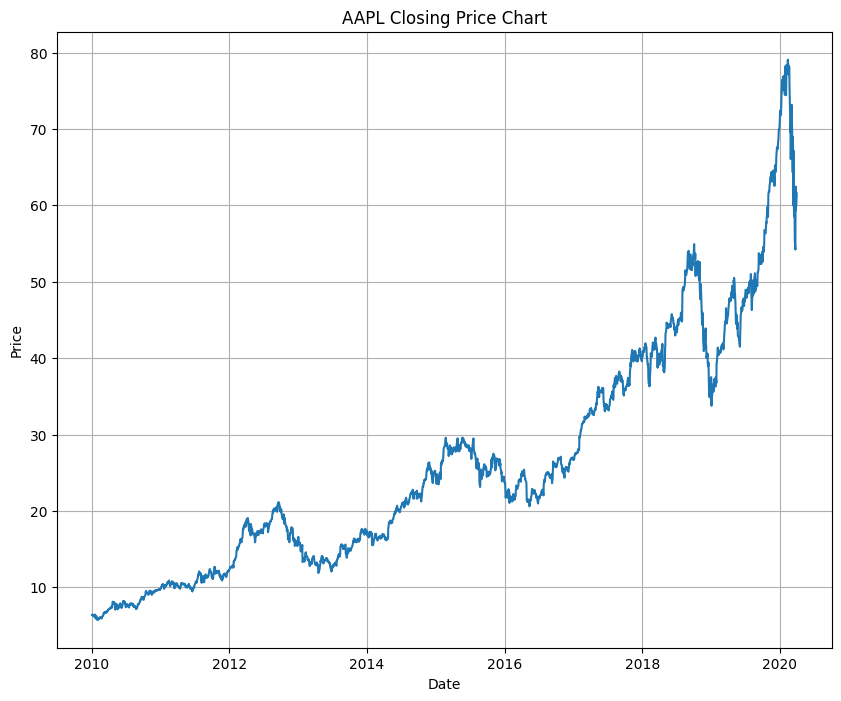

In [24]:
# First, check what columns are available in your DataFrame
print(df.columns)

# Then use the correct column name in your plot
plt.figure(figsize=(10,8))
# Assuming the column is named 'Close' instead of 'Adj Close'
plt.plot(df['Close'])  # Changed from 'Adj Close' to 'Close'
plt.title(stock + ' Closing Price Chart')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# High and Low prices 

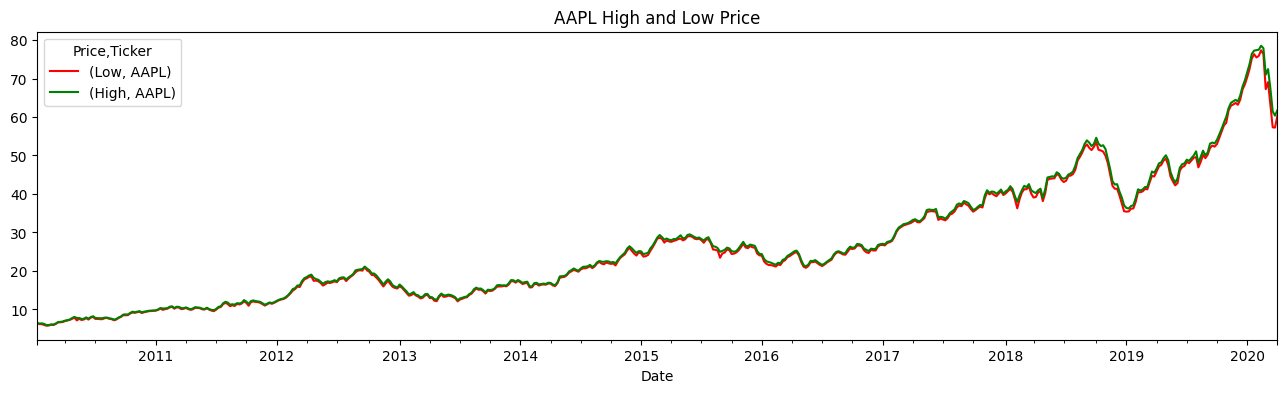

In [28]:
#fig, ax = plt.subplots(figsize=(16, 4))
#(df.groupby(pd.Grouper(freq='W'))[['Low','High']]).mean().plot(color=['Red', 'Green'], ax=ax, title=stock+' High and Low Price ')


fig, ax = plt.subplots(figsize=(16, 4))

# First, ensure we have the necessary imports
import pandas as pd
import matplotlib.pyplot as plt

# Check if 'stock' variable is defined, if not define it with a default value
if 'stock' not in locals():
    stock = "Stock"  # Default value if stock is not defined

# Check if 'Date' column exists in the DataFrame
if 'Date' in df.columns:
    # Make sure Date is in datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Set Date as index if it's not already the index
    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.set_index('Date')
else:
    # If no Date column, check if index is already a DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        # Try to convert the first column to datetime if it might be a date
        try:
            date_col = df.columns[0]
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.set_index(date_col)
        except:
            raise ValueError("No date column found in the DataFrame")

# Now that we have a DatetimeIndex, we can use resample instead of groupby with Grouper
# This is more reliable for time-based operations
df[['Low', 'High']].resample('W').mean().plot(
    color=['Red', 'Green'], 
    ax=ax, 
    title=stock + ' High and Low Price'
)

plt.show()  # Display the plot

# Weekly Stock Analysis Average

In [29]:
weekly_avg = df.resample('W').mean()
weekly_avg

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-10,1970-01-01 00:00:00.000000006,6.408009,6.319138,6.378885,5.145073e+08
2010-01-17,1970-01-01 00:00:00.000000006,6.326749,6.195511,6.297625,5.379086e+08
2010-01-24,1970-01-01 00:00:00.000000005,6.378749,6.150731,6.307962,7.080206e+08
2010-01-31,1970-01-01 00:00:00.000000005,6.212470,5.940166,6.120364,1.414967e+09
2010-02-07,1970-01-01 00:00:00.000000005,5.914039,5.762006,5.829663,7.343011e+08
...,...,...,...,...,...
2020-03-08,1970-01-01 00:00:00.000000070,72.449602,69.070706,70.550423,2.587602e+08
2020-03-15,1970-01-01 00:00:00.000000064,67.446008,63.073060,64.712737,3.233679e+08


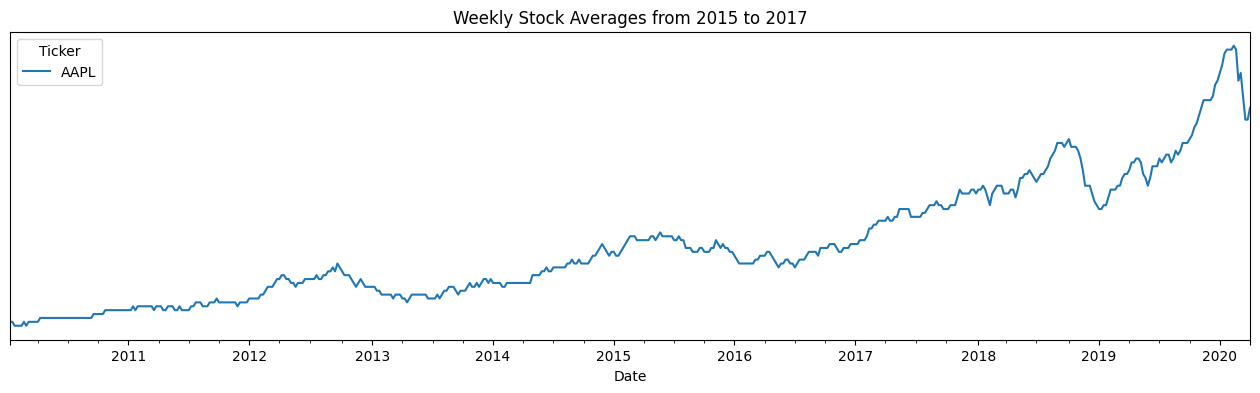

In [32]:
#fig, ax = plt.subplots(figsize=(16, 4))
#weekly_avg['Adj Close'].plot(title='Weekly Stock Averages from 2015 to 2017', ax=ax)

fig, ax = plt.subplots(figsize=(16, 4))

# Check if 'Adj Close' exists in the DataFrame, otherwise use an available column
# Option 1: If you know another column exists that you want to plot instead
if 'Adj Close' in weekly_avg.columns:
    weekly_avg['Adj Close'].plot(title='Weekly Stock Averages from 2015 to 2017', ax=ax)
else:
    # Replace 'Close' with an actual column name that exists in your DataFrame
    weekly_avg['Close'].plot(title='Weekly Stock Averages from 2015 to 2017', ax=ax)
    
# Option 2: If you want to see what columns are available first
# print(weekly_avg.columns)

# Monthly Returns
## Create new column 'Returns', 'Month_Name', Month_name_Year', and 'Month' 
## for compute closing price each month

In [73]:
#monthly = df.asfreq('BM')
#monthly['Returns'] = df['Close'].pct_change().dropna() # pct_change: Percentage change between the current and a prior element.

#monthly['Month_Name'] = monthly.index.strftime("%b")
#monthly['Month_Name_Year'] = monthly.index.strftime("%b-%Y")

#monthly = monthly.reset_index()
#monthly['Month'] = monthly["Date"].dt.month

import pandas as pd

# Flatten MultiIndex columns if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only one Close column
df = df.loc[:, ~df.columns.duplicated()]

# Make sure index is datetime
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

monthly = df.asfreq('BME')

monthly['Close'] = pd.to_numeric(monthly['Close'], errors='coerce')
monthly['Returns'] = monthly['Close'].pct_change(fill_method=None)

monthly['Month_Name'] = monthly.index.strftime("%b")
monthly['Month_Name_Year'] = monthly.index.strftime("%b-%Y")

monthly = monthly.dropna(subset=['Returns']).reset_index()

if 'Date' in monthly.columns:
    monthly['Month'] = monthly['Date'].dt.month
else:
    monthly['Month'] = monthly.iloc[:, 0].dt.month

print(monthly.head())

Price       Date                Close      High       Low      Open  \
0     2010-02-26                    6  6.147510  6.052527  6.063913   
1     2010-03-31                    7  7.089548  7.025127  7.055990   
2     2010-04-30                    7  8.107089  7.820344  8.069336   
3     2010-05-31 -9223372036854775808       NaN       NaN       NaN   
4     2010-06-30                    7  7.729561  7.491056  7.691807   

Price       Volume       Returns Month_Name Month_Name_Year  Month  
0      507460800.0  2.000000e-01        Feb        Feb-2010      2  
1      430659600.0  1.666667e-01        Mar        Mar-2010      3  
2      542463600.0  0.000000e+00        Apr        Apr-2010      4  
3              NaN -1.317625e+18        May        May-2010      5  
4      739452000.0 -1.000000e+00        Jun        Jun-2010      6  


In [74]:
monthly.head()

Price,Date,Close,High,Low,Open,Volume,Returns,Month_Name,Month_Name_Year,Month
0,2010-02-26,6,6.147510,6.052527,6.063913,507460800.0,2.000000e-01,Feb,Feb-2010,2
1,2010-03-31,7,7.089548,7.025127,7.055990,430659600.0,1.666667e-01,Mar,Mar-2010,3
2,2010-04-30,7,8.107089,7.820344,8.069336,542463600.0,0.000000e+00,Apr,Apr-2010,4
3,2010-05-31,-9223372036854775808,NaN,NaN,NaN,NaN,-1.317625e+18,May,May-2010,5
4,2010-06-30,7,7.729561,7.491056,7.691807,739452000.0,-1.000000e+00,Jun,Jun-2010,6


In [82]:
monthly['ReturnsPositive'] = 0 < monthly['Returns']
monthly['Date'] = pd.to_datetime(monthly['Date'])
monthly['Date'] = monthly['Date'].apply(mdates.date2num)

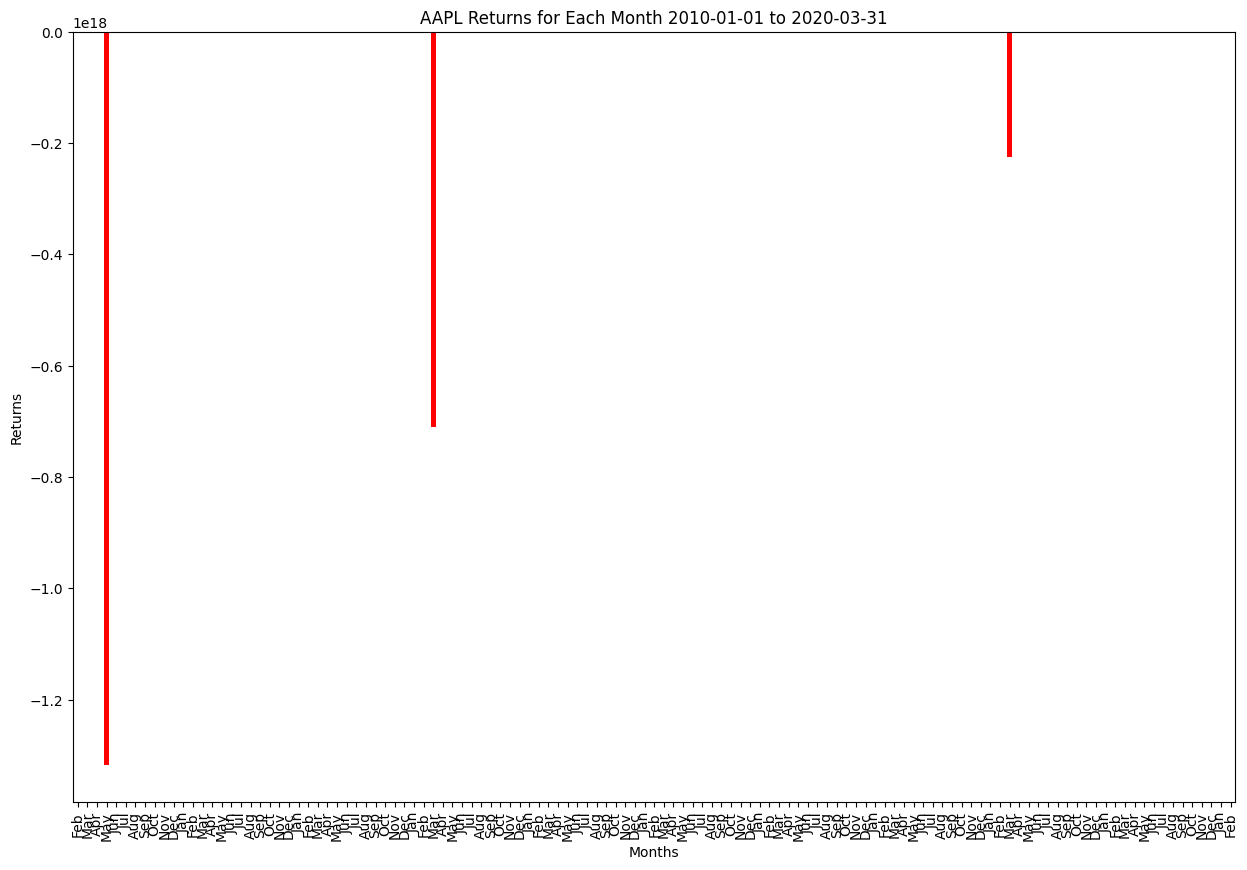

In [81]:
colors = monthly.ReturnsPositive.map({True: 'g', False: 'r'})
monthly['Returns'].plot(kind='bar', color = colors, figsize=(15,10))
plt.xlabel("Months")
plt.ylabel("Returns")
plt.title(stock + " Returns for Each Month " + str(start) + ' to ' + str(end))
plt.xticks(monthly.index, monthly['Month_Name'])
plt.show()

# Yearly returns

In [89]:
yearly = df[['Close']].asfreq('BYE').copy()

yearly['Close'] = pd.to_numeric(yearly['Close'], errors='coerce')

yearly['Returns'] = yearly['Close'].pct_change(fill_method=None)

yearly = yearly.dropna(subset=['Returns']).reset_index()

yearly['Years'] = yearly.iloc[:, 0].dt.year

print("Yearly:")
print(yearly.head())

Yearly:
Price       Date  Close   Returns  Years
0     2011-12-30     12  0.333333   2011
1     2012-12-31     16  0.333333   2012
2     2013-12-31     17  0.062500   2013
3     2014-12-31     24  0.411765   2014
4     2015-12-31     23 -0.041667   2015


In [90]:
yearly['ReturnsPositive'] = 0 < yearly['Returns']
yearly['Date'] = pd.to_datetime(yearly['Date'])
yearly['Date'] = yearly['Date'].apply(mdates.date2num)

<Figure size 640x480 with 0 Axes>

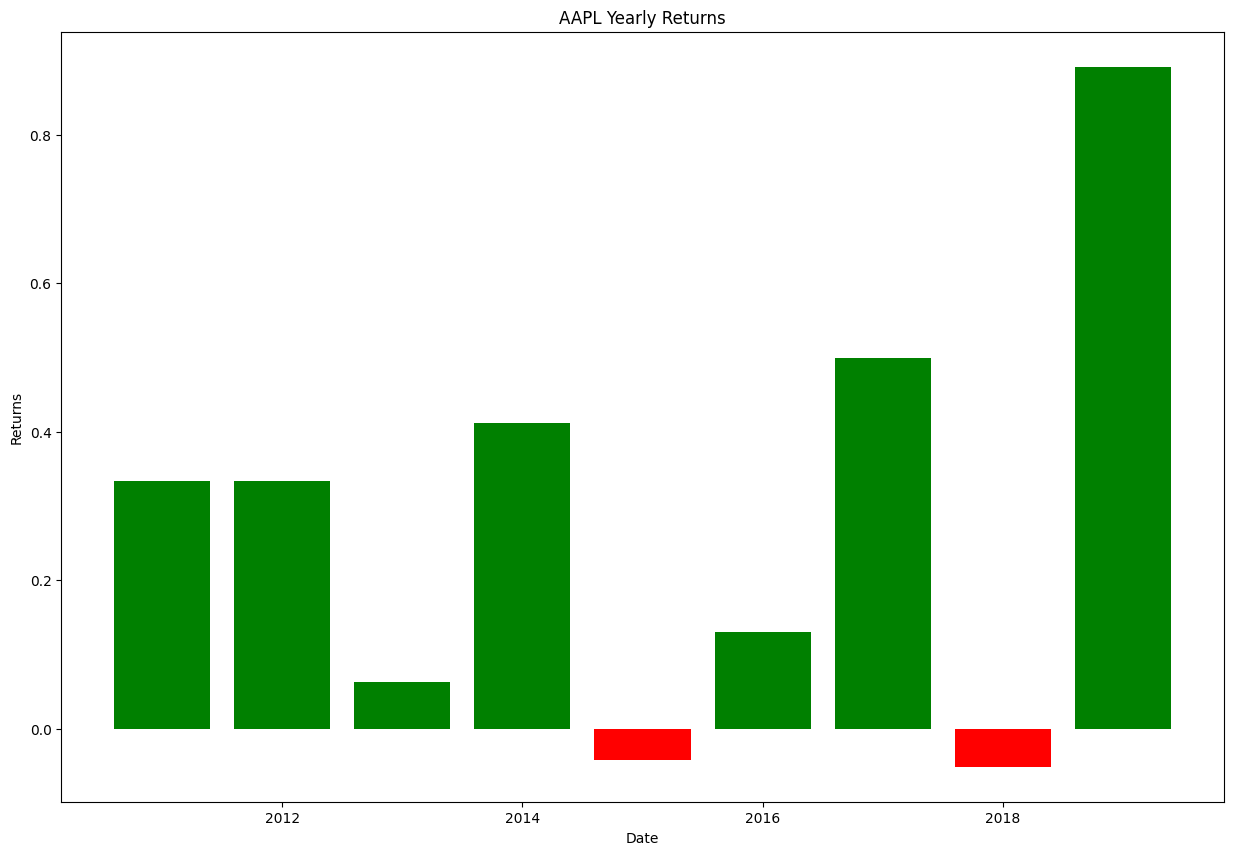

In [91]:
colors = yearly.ReturnsPositive.map({True: 'g', False: 'r'})
plt.gcf()
plt.gcf()
plt.figure(figsize=(15,10))
plt.bar(yearly['Years'], yearly['Returns'], color=colors, align='center')
plt.title(stock + ' Yearly Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

# Yearly Returns Avg

In [99]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
else:
    df.index = pd.to_datetime(df.index)
price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
df['Returns'] = pd.to_numeric(df[price_col], errors='coerce').pct_change(fill_method=None)
df = df.dropna(subset=['Returns'])
yearly_returns_avg = df['Returns'].groupby(df.index.year).mean()
print(yearly_returns_avg)

1970    0.00131
Name: Returns, dtype: float64


#### Rename columns in dataset to ***ds*** as X [featuer] which is goin to be date, and **y** as lable or class which is Adj Close price, to fit the defualt column names in Prophet model. this is reqiered to rename columns names.

In [100]:
df = df.reset_index().rename(columns={'Date':'ds', 'Adj Close':'y'})
# df['ds'] = pd.to_datetime(df.index)  # the ds column must be converted to pd.to_datetime()
# df['ds'] = pd.to_datetime(df['ds'])  # the ds column must be converted to pd.to_datetime()
#df['y'] = pd.DataFrame(df['Adj Close'])

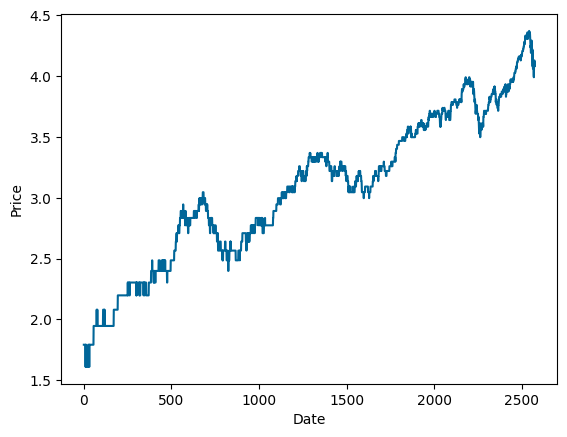

In [102]:
# Log Transform Data
price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
df['y'] = np.log(pd.to_numeric(df[price_col], errors='coerce'))

# plot data
ax = df['y'].plot(color='#006699')
ax.set_ylabel('Price')
ax.set_xlabel('Date')
plt.show()

# Data processings : creating training and testing data

In [103]:
size,_=df.shape
split_size=0.3
test_size=int(size*split_size)
train_size=size-test_size

print(f'Dataset size={size}')
print(f'Train size={train_size}')
print(f'Test size={test_size}')

Dataset size=2574
Train size=1802
Test size=772


In [104]:
# split data into train and test
test_size = int(df.shape[0]*split_size) # days

df_train = df[:-test_size]
df_test = df[-test_size:]

In [105]:
df_train

Price,index,ds,Close,High,Low,Open,Volume,Returns,y
0,1970-01-01 00:00:00.000000003,2010-01-07,1970-01-01 00:00:00.000000006,6.352157,6.263766,6.344667,477131200,0.000000,1.791759
1,1970-01-01 00:00:00.000000004,2010-01-08,1970-01-01 00:00:00.000000006,6.352158,6.264067,6.301220,447610800,0.000000,1.791759
2,1970-01-01 00:00:00.000000005,2010-01-11,1970-01-01 00:00:00.000000006,6.382120,6.245789,6.376127,462229600,0.000000,1.791759
3,1970-01-01 00:00:00.000000006,2010-01-12,1970-01-01 00:00:00.000000006,6.285340,6.184964,6.267961,594459600,0.000000,1.791759
4,1970-01-01 00:00:00.000000007,2010-01-13,1970-01-01 00:00:00.000000006,6.320097,6.115450,6.228411,605892000,0.000000,1.791759
...,...,...,...,...,...,...,...,...,...
1797,1970-01-01 00:00:00.000001800,2017-02-28,1970-01-01 00:00:00.000000031,31.785505,31.614365,31.702248,93931600,0.000000,3.433987
1798,1970-01-01 00:00:00.000001801,2017-03-01,1970-01-01 00:00:00.000000032,32.412251,31.822520,31.889586,145658400,0.032258,3.465736
1799,1970-01-01 00:00:00.000001802,2017-03-02,1970-01-01 00:00:00.000000032,32.442315,32.090787,32.377560,104844000,0.000000,3.465736
1800,1970-01-01 00:00:00.000001803,2017-03-03,1970-01-01 00:00:00.000000032,32.338243,32.051469,32.095411,84432400,0.000000,3.465736


In [106]:
df_test

Price,index,ds,Close,High,Low,Open,Volume,Returns,y
1802,1970-01-01 00:00:00.000001805,2017-03-07,1970-01-01 00:00:00.000000032,32.372941,32.097731,32.160175,69785200,0.000000,3.465736
1803,1970-01-01 00:00:00.000001806,2017-03-08,1970-01-01 00:00:00.000000032,32.331309,32.104667,32.134730,74828800,0.000000,3.465736
1804,1970-01-01 00:00:00.000001807,2017-03-09,1970-01-01 00:00:00.000000032,32.097713,31.695308,32.086152,88623600,0.000000,3.465736
1805,1970-01-01 00:00:00.000001808,2017-03-10,1970-01-01 00:00:00.000000032,32.229556,32.063042,32.204116,78451200,0.000000,3.465736
1806,1970-01-01 00:00:00.000001809,2017-03-13,1970-01-01 00:00:00.000000032,32.245738,32.104667,32.111605,69686800,0.000000,3.465736
...,...,...,...,...,...,...,...,...,...
2569,1970-01-01 00:00:00.000002572,2020-03-24,1970-01-01 00:00:00.000000059,59.848331,56.612960,57.110709,287531200,0.092593,4.077537
2570,1970-01-01 00:00:00.000002573,2020-03-25,1970-01-01 00:00:00.000000059,62.399890,59.029210,60.587696,303602000,0.000000,4.077537
2571,1970-01-01 00:00:00.000002574,2020-03-26,1970-01-01 00:00:00.000000062,62.503792,59.526963,59.565624,252087200,0.050847,4.127134
2572,1970-01-01 00:00:00.000002575,2020-03-27,1970-01-01 00:00:00.000000059,61.824829,59.693690,61.070957,204216800,-0.048387,4.077537


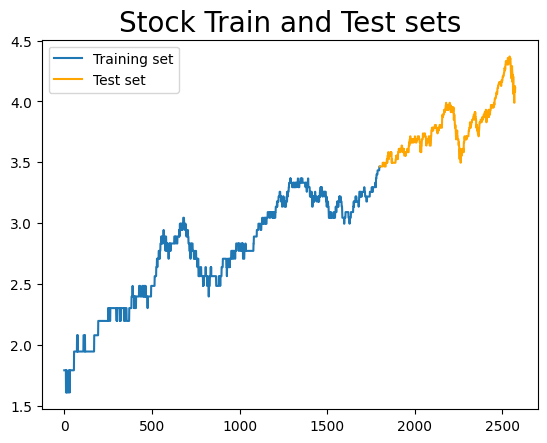

In [107]:
plt.title('Stock Train and Test sets', size=20)
plt.plot(df_train['y'], label='Training set')
plt.plot(df_test['y'], label='Test set', color='orange')
plt.legend();

# Model Fitting with train data

### Ref:
https://facebook.github.io/prophet/docs/uncertainty_intervals.html

#### Description
Make dataframe with future dates for forecasting. 

#### Usage
* make_future_dataframe(m, periods, freq = "day", include_history = TRUE)
#### Arguments
m : Prophet model object.
periods : Int number of periods to forecast forward.

freq : 'day', 'week', 'month', 'quarter', 'year', 1(1 sec), 60(1 minute) or 3600(1 hour).

include_history : Boolean to include the historical dates in the data frame for predictions.

In [108]:
# Model Fitting
# instantiate the Prophet class
mdl = Prophet(interval_width=0.95, daily_seasonality=True)


In [109]:

# fit the model on the training data
mdl.fit(df)
# mdl.fit(X_train)
 

14:37:25 - cmdstanpy - INFO - Chain [1] start processing
14:37:27 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
# define future time frame
future = mdl.make_future_dataframe(periods=24, freq='MS', include_history = True) # periods 24 months later ( in future )
# future = mdl.make_future_dataframe(periods=24, freq='MS', include_history = False) # periods 24 months later ( in future )


In [111]:
future

,ds
0,2010-01-07
1,2010-01-08
2,2010-01-11
3,2010-01-12
4,2010-01-13
...,...
2593,2021-11-01
2594,2021-12-01
2595,2022-01-01
2596,2022-02-01


In [112]:
# generate the forecast
forecast = mdl.predict(future)

#use df_test
# forecast = mdl.predict(df_test)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2010-01-07,1.731003,1.582795,1.871739
1,2010-01-08,1.730826,1.578084,1.876621
2,2010-01-11,1.737774,1.596573,1.884236
3,2010-01-12,1.739785,1.592134,1.893524
4,2010-01-13,1.740185,1.580429,1.887143
...,...,...,...,...
2593,2021-11-01,4.525544,3.201398,6.043546
2594,2021-12-01,4.515517,3.096953,6.130935
2595,2022-01-01,4.505765,2.981840,6.202046
2596,2022-02-01,4.504040,2.835577,6.312817


In [113]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-01-07,1.776591,1.582795,1.871739,1.776591,1.776591,-0.045587,-0.045587,-0.045587,-0.03335,...,-0.001629,-0.001629,-0.001629,-0.010609,-0.010609,-0.010609,0.0,0.0,0.0,1.731003
1,2010-01-08,1.777913,1.578084,1.876621,1.777913,1.777913,-0.047087,-0.047087,-0.047087,-0.03335,...,-0.003789,-0.003789,-0.003789,-0.009948,-0.009948,-0.009948,0.0,0.0,0.0,1.730826
2,2010-01-11,1.781880,1.596573,1.884236,1.781880,1.781880,-0.044106,-0.044106,-0.044106,-0.03335,...,-0.001488,-0.001488,-0.001488,-0.009268,-0.009268,-0.009268,0.0,0.0,0.0,1.737774
3,2010-01-12,1.783202,1.592134,1.893524,1.783202,1.783202,-0.043417,-0.043417,-0.043417,-0.03335,...,-0.000524,-0.000524,-0.000524,-0.009543,-0.009543,-0.009543,0.0,0.0,0.0,1.739785
4,2010-01-13,1.784525,1.580429,1.887143,1.784525,1.784525,-0.044340,-0.044340,-0.044340,-0.03335,...,-0.000907,-0.000907,-0.000907,-0.010083,-0.010083,-0.010083,0.0,0.0,0.0,1.740185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2593,2021-11-01,4.514708,3.201398,6.043546,3.178436,6.040576,0.010836,0.010836,0.010836,-0.03335,...,-0.001488,-0.001488,-0.001488,0.045675,0.045675,0.045675,0.0,0.0,0.0,4.525544
2594,2021-12-01,4.532839,3.096953,6.130935,3.090020,6.155369,-0.017322,-0.017322,-0.017322,-0.03335,...,-0.000907,-0.000907,-0.000907,0.016935,0.016935,0.016935,0.0,0.0,0.0,4.515517
2595,2022-01-01,4.551574,2.981840,6.202046,3.004849,6.240873,-0.045809,-0.045809,-0.045809,-0.03335,...,0.004169,0.004169,0.004169,-0.016628,-0.016628,-0.016628,0.0,0.0,0.0,4.505765
2596,2022-02-01,4.570310,2.835577,6.312817,2.914102,6.336814,-0.066270,-0.066270,-0.066270,-0.03335,...,-0.000524,-0.000524,-0.000524,-0.032395,-0.032395,-0.032395,0.0,0.0,0.0,4.504040


In [114]:
# mae = mean_absolute_error(forecast, df['y'])
# mae = mean_absolute_error(df_test['y'], forecast['yhat'])
mae = mean_absolute_error(forecast['yhat'][:df.shape[0]],df['y'])
print('MAE: %.3f' % mae)

MAE: 0.058


In [115]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mse=mean_squared_error(forecast['yhat'][:df.shape[0]],df['y'])
r2=r2_score(forecast['yhat'][:df.shape[0]],df['y'])
print(f'MSE ={mse}\nAccurecy ={r2}')

MSE =0.005910918263739483
Accurecy =0.9841882945814994


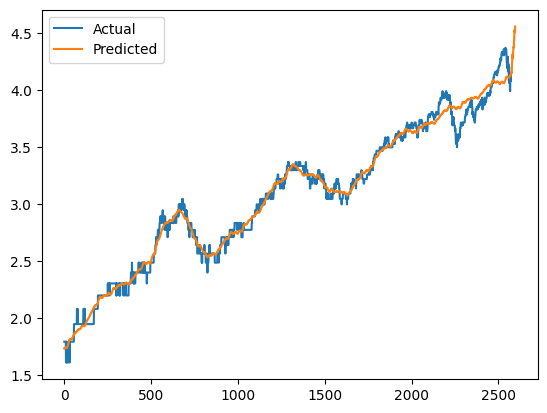

In [116]:
# plot expected vs actual
plt.plot(df['y'], label='Actual')
plt.plot(forecast['yhat'], label='Predicted')
plt.legend()
plt.show()

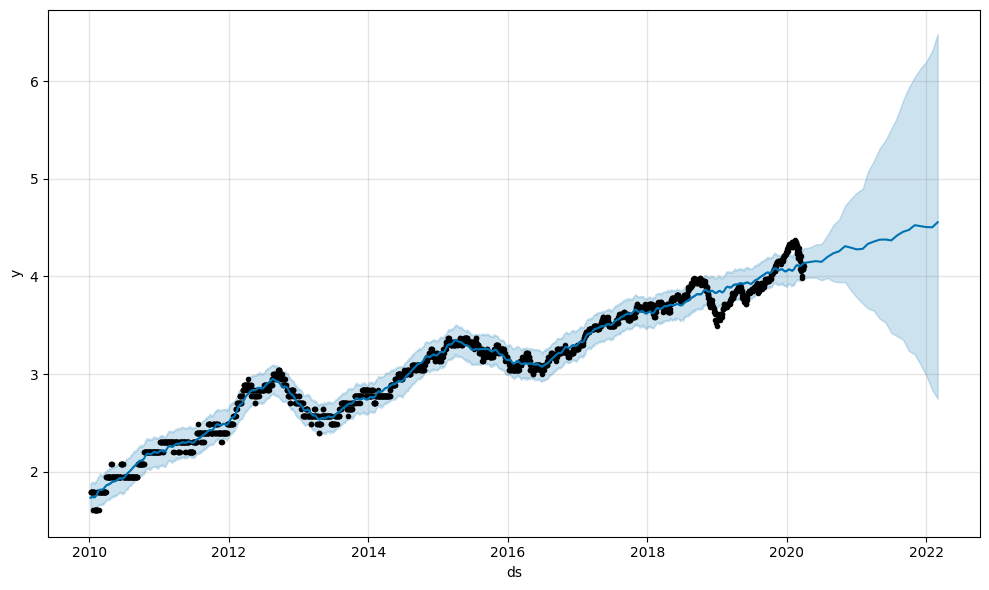

In [117]:
mdl.plot(forecast);
plt.show()

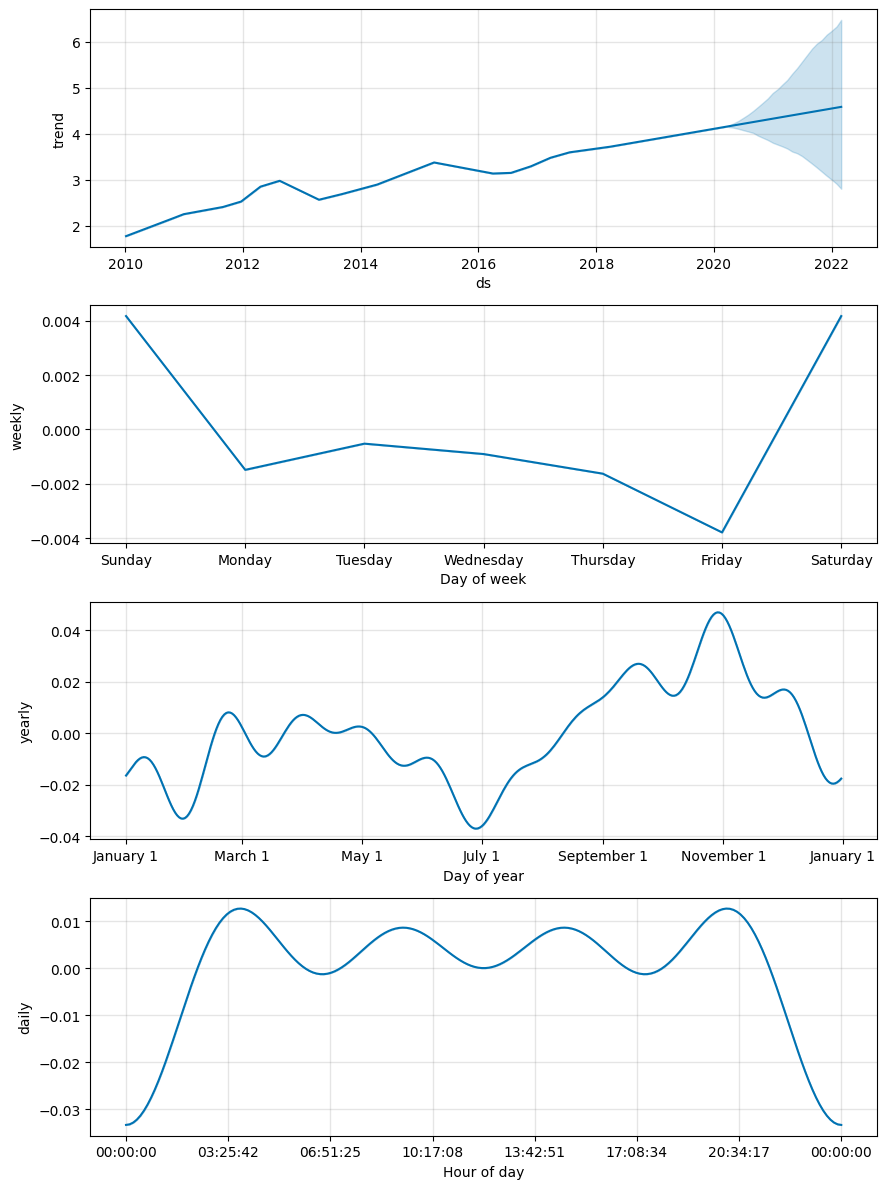

<Figure size 640x480 with 0 Axes>

In [118]:
# plot time series components
mdl.plot_components(forecast)
plt.show()
plt.savefig('foo.png')

In [119]:
# retransform using e
y_hat = np.exp(forecast['yhat'][:740])
y_true = np.exp(df['y'])
 
# compute the mean square error
mse = ((y_hat - y_true) ** 2).mean()
# mse = ((forecast['yhat'][:740] - df['y']) ** 2).mean()


print('Prediction quality: {:.2f} MSE ({:.2f} RMSE)'.format(mse, math.sqrt(mse)))

Prediction quality: 0.60 MSE (0.77 RMSE)


In [120]:
se = np.square(forecast.loc[:df.shape[0], 'yhat'] - df['y'])
mse = np.mean(se)
rmse = np.sqrt(mse)
rmse

np.float64(0.07688249647182044)

In [121]:
mae = mean_absolute_error(forecast.loc[:df.shape[0]-1, 'yhat'], df['y'])
print('MAE: %.3f' % mae)

MAE: 0.058


In [122]:
df['y']

0       1.791759
1       1.791759
2       1.791759
3       1.791759
4       1.791759
          ...   
2569    4.077537
2570    4.077537
2571    4.127134
2572    4.077537
2573    4.110874
Name: y, Length: 2574, dtype: float64

In [123]:
forecast['yhat'][:740]

0      1.731003
1      1.730826
2      1.737774
3      1.739785
4      1.740185
         ...   
735    2.766364
736    2.758669
737    2.755903
738    2.751641
739    2.746928
Name: yhat, Length: 740, dtype: float64

In [124]:
forecast.loc[:739, 'yhat']

0      1.731003
1      1.730826
2      1.737774
3      1.739785
4      1.740185
         ...   
735    2.766364
736    2.758669
737    2.755903
738    2.751641
739    2.746928
Name: yhat, Length: 740, dtype: float64

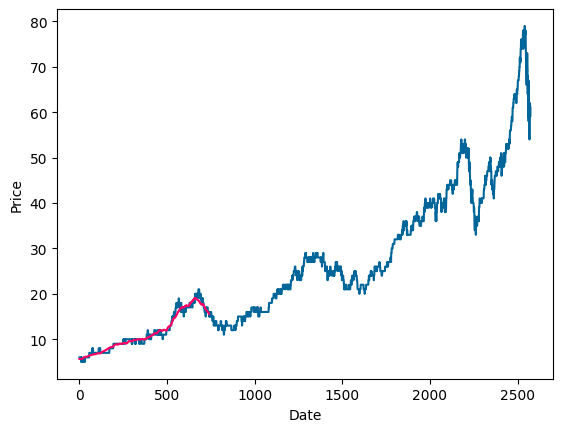

In [125]:
plt.plot(y_true, label='Original', color='#006699');
plt.plot(y_hat, color='#ff0066', label='Forecast');
plt.ylabel('Price');
plt.xlabel('Date');
plt.show()

In [128]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 31.0 MB/s  0:00:00 eta 0:00:01


In [129]:
import plotly.io as pio
pio.renderers.default = 'iframe'


In [138]:
import plotly
import plotly.graph_objs as go
import plotly.io as pio

pio.renderers.default = 'iframe'

In [141]:
from prophet.plot import plot_plotly

In [143]:
!pip install plotly prophet --upgrade

In [155]:
import plotly.graph_objs as go
import plotly.io as pio

pio.renderers.default = 'iframe'

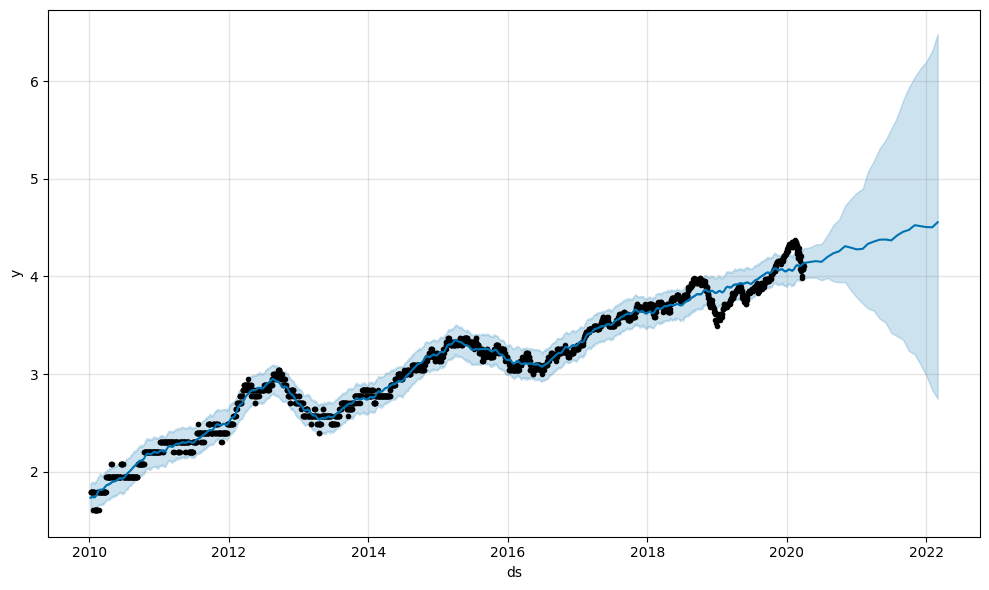

In [157]:
fig = mdl.plot(forecast)
plt.show()

In [158]:
#plot_plotly(mdl, forecast)